# データ分析 03：事業所統計分析
## 中央区における経営組織構成の状況

### 分析対象

- **データソース**: e-Stat（政府統計の総合窓口）事業所・企業統計
- **統計ID**: 0004040084（経営組織別・産業大分類別の事業所数）
- **分析対象**: 福岡市中央区の事業所データ
- **時点**: 2024年
- **主要指標**: 個人経営 vs 法人経営の構成比（%）

### 分析の限定事項

- **一時点分析**: 2024年のスナップショットであり、時系列比較なし
- **単一地域**: 福岡市中央区のみの分析であり、全国比較なし
- **記述的分析**: データの事実の記述に留める

### 分析範囲

本分析は統計データの客観的な記述に留めます。データの解釈や見解については、99の統合分析レポートを参照してください。

In [4]:
# セクション1：必要なライブラリのインポート
import pandas as pd
import numpy as np
import requests
import json
import io
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# 日本語フォント設定（macOS）
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Yu Gothic']
plt.rcParams['axes.unicode_minus'] = False

print("✓ ライブラリのインポート完了")

✓ ライブラリのインポート完了


## セクション2：環境変数からAPIキーを読み込む

In [5]:
# .envファイルから環境変数を読み込む
env_path = Path('../.env')
load_dotenv(env_path)

APP_ID = os.getenv('APP_ID')
if not APP_ID:
    raise ValueError("❌ APP_IDが.envで設定されていません。APP_ID=<your_app_id> を設定してください。")

print(f"✓ APP_IDを読み込みました（先頭8文字: {APP_ID[:8]}...）")

✓ APP_IDを読み込みました（先頭8文字: cc6bf7f0...）


## セクション3：e-Stat APIからJSONデータを取得

In [7]:
# e-Stat APIからデータを取得
# 統計ID: 0004040084（経営組織別・産業大分類別の事業所数）

cache_dir = Path('../input_data')
cache_dir.mkdir(parents=True, exist_ok=True)
cache_file = cache_dir / 'estat_tenant_data.json'

def fetch_estat_data(app_id, stats_data_id, cache_path, retry_count=3):
    """
    e-Stat APIからJSONデータを取得（キャッシュ・リトライ機能付き）
    
    Args:
        app_id (str): e-Stat App ID
        stats_data_id (str): 統計ID
        cache_path (Path): キャッシュファイルパス
        retry_count (int): リトライ回数
    
    Returns:
        dict: APIレスポンスのJSONデータ
    """
    # キャッシュが存在すれば使用
    if cache_path.exists():
        print(f"✓ キャッシュから読み込み: {cache_path.name}")
        with open(cache_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    
    # キャッシュがなければAPIから取得
    print(f"⇩ e-Stat APIからダウンロード中（統計ID: {stats_data_id}）...")
    
    api_url = 'http://api.e-stat.go.jp/rest/3.0/app/json/getStatsData'
    params = {
        'appId': app_id,
        'lang': 'J',
        'statsDataId': stats_data_id,
        'metaGetFlg': 'Y',
        'cntGetFlg': 'N',
        'explanationGetFlg': 'Y',
        'annotationGetFlg': 'Y',
        'sectionHeaderFlg': 1,
        'replaceSpChars': 0
    }
    
    for attempt in range(retry_count):
        try:
            print(f"  接続試行: {attempt+1}/{retry_count} (タイムアウト: 60秒)...")
            # タイムアウトを60秒に延長（e-Stat APIは大量データを返す可能性）
            response = requests.get(api_url, params=params, timeout=60)
            response.raise_for_status()
            data = response.json()
            
            # キャッシュに保存
            with open(cache_path, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
            
            print(f"✓ ダウンロード完了 & キャッシュ保存")
            return data
            
        except requests.exceptions.Timeout as e:
            print(f"  ⚠ タイムアウト: {e}")
            if attempt < retry_count - 1:
                print(f"  再試行します...")
                continue
            else:
                raise
        except requests.exceptions.RequestException as e:
            print(f"❌ APIエラー: {e}")
            raise

# データを取得
try:
    GET_STATS_DATA = fetch_estat_data(APP_ID, '0004040084', cache_file)
except Exception as e:
    print(f"\n❌ e-Stat APIからのダウンロードに失敗しました。")
    print(f"原因: {type(e).__name__}")
    print(f"\n【代替方法】")
    print(f"1. しばらく待ってから再実行してください")
    print(f"2. キャッシュファイルが {cache_file} に存在することを確認してください")
    print(f"3. e-Stat APIの status ページを確認してください")
    raise

# APIレスポンスの構造確認
print(f"\n【APIレスポンス構造】")
print(f"Status: {GET_STATS_DATA.get('GET_STATS_DATA', {}).get('RESULT', {}).get('STATUS')}")
if 'STATISTICAL_DATA' in GET_STATS_DATA.get('GET_STATS_DATA', {}):
    stat_data = GET_STATS_DATA['GET_STATS_DATA']['STATISTICAL_DATA']
    print(f"データレコード数: {len(stat_data.get('DATA_INF', {}).get('VALUE', []))}")
    print(f"メタデータ: {len(stat_data.get('CLASS_INF', {}).get('CLASS_OBJ', []))} 個のクラス")

⇩ e-Stat APIからダウンロード中（統計ID: 0004040084）...
  接続試行: 1/3 (タイムアウト: 60秒)...
  ⚠ タイムアウト: HTTPConnectionPool(host='api.e-stat.go.jp', port=80): Read timed out. (read timeout=60)
  再試行します...
  接続試行: 2/3 (タイムアウト: 60秒)...
  ⚠ タイムアウト: HTTPConnectionPool(host='api.e-stat.go.jp', port=80): Read timed out. (read timeout=60)
  再試行します...
  接続試行: 3/3 (タイムアウト: 60秒)...
✓ ダウンロード完了 & キャッシュ保存

【APIレスポンス構造】
Status: 0
データレコード数: 100000
メタデータ: 6 個のクラス


## セクション4：JSONデータをフラットなDataFrameに変換

In [29]:
# JSONをフラットなDataFrameに変換
print("\n【DataFrameの初期状態】")

# 属性名（@で始まる）と値（$）を抽出
records = []
stat_data = GET_STATS_DATA['GET_STATS_DATA']['STATISTICAL_DATA']
value_data = stat_data.get('DATA_INF', {}).get('VALUE', [])

for val_record in value_data:
    record = {}
    for key, value in val_record.items():
        if key == '$':  # 統計値
            try:
                record['value'] = int(value)
            except ValueError:
                # 秘匿情報（'***'など）はNULLにする
                record['value'] = None
        elif key.startswith('@'):  # 属性
            record[key[1:]] = value  # @を削除してキー名に
    records.append(record)

df_raw = pd.DataFrame(records)
print(f"形状: {df_raw.shape}")
print(f"カラム: {df_raw.columns.tolist()}")
print(f"\n最初の3行:")
print(df_raw.head(3))


【DataFrameの初期状態】
形状: (100000, 8)
カラム: ['tab', 'cat01', 'cat02', 'cat03', 'area', 'time', 'unit', 'value']

最初の3行:
        tab cat01 cat02 cat03   area        time unit      value
0  102-2024    AR    00     0  00000  2024000000  事業所  4023941.0
1  102-2024    AR    00     0  01000  2024000000  事業所   169567.0
2  102-2024    AR    00     0  01100  2024000000  事業所    62676.0


In [27]:
# データ構造の詳細診断
print("="*80)
print("【APIレスポンス構造の詳細診断】")
print("="*80)

stat_data = GET_STATS_DATA['GET_STATS_DATA']['STATISTICAL_DATA']

# VALUEデータの構造を確認
print(f"\nVALUEデータのサンプル（最初の3件）:")
value_data = stat_data.get('DATA_INF', {}).get('VALUE', [])
if value_data:
    for i, val_record in enumerate(value_data[:3]):
        print(f"\n[{i}] {type(val_record)}: {val_record}")

# 最初のレコードの構造を詳しく見る
if value_data:
    first_val = value_data[0]
    print(f"\n【最初のレコードの詳細】")
    if isinstance(first_val, dict):
        for key, value in first_val.items():
            print(f"  {key}: {value} ({type(value).__name__})")


【APIレスポンス構造の詳細診断】

VALUEデータのサンプル（最初の3件）:

[0] <class 'dict'>: {'@tab': '102-2024', '@cat01': 'AR', '@cat02': '00', '@cat03': '0', '@area': '00000', '@time': '2024000000', '@unit': '事業所', '$': '4023941'}

[1] <class 'dict'>: {'@tab': '102-2024', '@cat01': 'AR', '@cat02': '00', '@cat03': '0', '@area': '01000', '@time': '2024000000', '@unit': '事業所', '$': '169567'}

[2] <class 'dict'>: {'@tab': '102-2024', '@cat01': 'AR', '@cat02': '00', '@cat03': '0', '@area': '01100', '@time': '2024000000', '@unit': '事業所', '$': '62676'}

【最初のレコードの詳細】
  @tab: 102-2024 (str)
  @cat01: AR (str)
  @cat02: 00 (str)
  @cat03: 0 (str)
  @area: 00000 (str)
  @time: 2024000000 (str)
  @unit: 事業所 (str)
  $: 4023941 (str)


## セクション5：メタデータを使用してコード値を名称に置換

In [30]:
# CLASS_OBJからメタデータを抽出（コード→名称のマッピング）
class_objs = stat_data['CLASS_INF']['CLASS_OBJ']

print("【メタデータ構造の確認】")
for i, class_obj in enumerate(class_objs[:2]):
    print(f"\nクラス {i}: {class_obj.get('@id')}")
    class_items = class_obj.get('CLASS', [])
    print(f"  CLASS型: {type(class_items)}")
    print(f"  最初の項目: {class_items[0] if class_items else 'なし'}")
    print(f"  最初の項目の型: {type(class_items[0]) if class_items else 'N/A'}")

# クラスごとのコード→名称マッピング辞書を作成
code_to_name_maps = {}

for class_obj in class_objs:
    class_id = class_obj['@id']
    code_to_name = {}
    
    class_items = class_obj.get('CLASS', [])
    
    # CLASS が辞書のリストか、文字列のリストかを判定
    if isinstance(class_items, list) and len(class_items) > 0:
        first_item = class_items[0]
        
        if isinstance(first_item, dict):
            # 通常のケース：辞書のリスト
            for class_item in class_items:
                code = class_item['@code']
                name = class_item['@name']
                code_to_name[code] = name
                
        elif isinstance(first_item, str):
            # 文字列のリストのケース
            for class_item in class_items:
                # 文字列から code と name を抽出（形式に応じて処理）
                if '@code' in class_item or '@name' in class_item:
                    # JSONフラット化された形式
                    try:
                        parts = class_item.split(':')
                        if len(parts) >= 2:
                            code_to_name[parts[0]] = parts[1]
                    except:
                        pass
    
    if len(code_to_name) > 0:
        code_to_name_maps[class_id] = code_to_name
        print(f"✓ {class_id}: {len(code_to_name)}個のマッピング")
    else:
        print(f"⚠ {class_id}: マッピングが見つかりません")

# DataFrameのカラムに対してコード→名称の置換を実施
df = df_raw.copy()

# 各カラムに対してコード置換
for col in df.columns:
    if col in code_to_name_maps:
        # コード値を名称に置換
        df[col] = df[col].map(code_to_name_maps[col])
        print(f"✓ カラム '{col}' をコード→名称に置換")

# value カラム（数値）を float型に変換
if 'value' in df.columns:
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    print(f"✓ カラム 'value' を float型に変換")

print(f"\n【置換後のDataFrame】")
print(f"形状: {df.shape}")
print(f"カラム: {df.columns.tolist()}")
print(df.head(5))

【メタデータ構造の確認】

クラス 0: tab
  CLASS型: <class 'list'>
  最初の項目: {'@code': '102-2024', '@name': '事業所数', '@level': '', '@unit': '事業所'}
  最初の項目の型: <class 'dict'>

クラス 1: cat01
  CLASS型: <class 'list'>
  最初の項目: {'@code': 'AR', '@name': '全産業（S_公務を除く）', '@level': '1'}
  最初の項目の型: <class 'dict'>
✓ tab: 3個のマッピング
✓ cat01: 130個のマッピング
✓ cat02: 11個のマッピング
✓ cat03: 6個のマッピング
✓ area: 1962個のマッピング
⚠ time: マッピングが見つかりません
✓ カラム 'tab' をコード→名称に置換
✓ カラム 'cat01' をコード→名称に置換
✓ カラム 'cat02' をコード→名称に置換
✓ カラム 'cat03' をコード→名称に置換
✓ カラム 'area' をコード→名称に置換
✓ カラム 'value' を float型に変換

【置換後のDataFrame】
形状: (100000, 8)
カラム: ['tab', 'cat01', 'cat02', 'cat03', 'area', 'time', 'unit', 'value']
    tab         cat01 cat02 cat03    area        time unit      value
0  事業所数  全産業（S_公務を除く）    総数    総数      全国  2024000000  事業所  4023941.0
1  事業所数  全産業（S_公務を除く）    総数    総数     北海道  2024000000  事業所   169567.0
2  事業所数  全産業（S_公務を除く）    総数    総数     札幌市  2024000000  事業所    62676.0
3  事業所数  全産業（S_公務を除く）    総数    総数  札幌市中央区  2024000000  事業所    19419

## セクション6：福岡市中央区のテナント均質化を分析

In [36]:
print("="*80)
print("【福岡市中央区：個人商店 vs 法人店舗の分析】")
print("="*80)

# 利用可能なデータ構造の確認
print(f"\n【データ構造】")
print(f"統計: e-Stat 0004040084（従業者規模別・経営組織別事業所数）")
print(f"対象: 全産業（S_公務を除く）")
print(f"時点: 2024年")

# 福岡市中央区のデータを抽出
area_col = 'area'
org_col = 'cat03'  # 経営組織カラムは cat03

df_chuo = df[df[area_col] == '福岡市中央区'].copy()
print(f"\n✓ 福岡市中央区のデータを抽出: {len(df_chuo)}レコード")

# 経営組織別に集計（従業者規模「総数」に限定）
df_chuo_target = df_chuo[df_chuo['cat02'] == '総数'].copy()
print(f"✓ 従業者規模「総数」のみを抽出: {len(df_chuo_target)}レコード")

# 経営組織ごとの事業所数を集計
org_sum = df_chuo_target.groupby(org_col)['value'].sum().sort_values(ascending=False)
print(f"\n【経営組織別の事業所数】")
print(org_sum)

# 個人 vs 法人の集計
print(f"\n【個人 vs 法人の構成】")
personal_types = ['個人', '個人（雇用者あり）']
corporate_types = ['法人', '会社', '会社以外の法人', '法人でない団体']

personal_count = org_sum[org_sum.index.isin(personal_types)].sum()
corporate_count = org_sum[org_sum.index.isin(corporate_types)].sum()
total_count = personal_count + corporate_count

if total_count > 0:
    personal_pct = personal_count / total_count * 100
    corporate_pct = corporate_count / total_count * 100
    print(f"個人経営: {personal_count:,.0f}件 ({personal_pct:.1f}%)")
    print(f"法人店舗: {corporate_count:,.0f}件 ({corporate_pct:.1f}%)")
    print(f"合計    : {total_count:,.0f}件")
else:
    print("❌ データがありません")

【福岡市中央区：個人商店 vs 法人店舗の分析】

【データ構造】
統計: e-Stat 0004040084（従業者規模別・経営組織別事業所数）
対象: 全産業（S_公務を除く）
時点: 2024年

✓ 福岡市中央区のデータを抽出: 51レコード
✓ 従業者規模「総数」のみを抽出: 6レコード

【経営組織別の事業所数】
cat03
総数           16749.0
法人           14523.0
会社           13125.0
個人（雇用者あり）     2140.0
会社以外の法人       1398.0
法人でない団体         86.0
Name: value, dtype: float64

【個人 vs 法人の構成】
個人経営: 2,140件 (6.8%)
法人店舗: 29,132件 (93.2%)
合計    : 31,272件


In [34]:
# グローバルなデータレベルを確認
print("\n【全データ（100000件）のcat02/cat03組合わせ】")
print("\ncat02の一意値の数:", df['cat02'].nunique())
print("\ncat03の一意値の数:", df['cat03'].nunique())

# areaとのクロス集計を見てみる
print("\n【area別のレコード数（トップ10）】")
area_counts = df.groupby('area').size().sort_values(ascending=False).head(10)
print(area_counts)

# 福岡市全体の産業別データを見てみる
df_fukuoka_all = df[df['area'].str.contains('福岡市', na=False)]
print(f"\n【福岡市全体データ】")
print(f"形状: {df_fukuoka_all.shape}")

# 福岡市内の全cat02を確認
print(f"\n福岡市内のcat02一意値:")
print(df_fukuoka_all['cat02'].unique())

# この統計IDが何を示しているのか確認する
print(f"\n【最初のレコード（詳細）】")
first_rec = df.iloc[0]
for col in df.columns:
    print(f"{col:10}: {first_rec[col]}")



【全データ（100000件）のcat02/cat03組合わせ】

cat02の一意値の数: 9

cat03の一意値の数: 6

【area別のレコード数（トップ10）】
area
池田町    204
美浜町    153
美郷町    153
南部町    153
美里町    153
朝日町    153
川上村    102
小国町    102
高森町    102
広川町    102
dtype: int64

【福岡市全体データ】
形状: (408, 8)

福岡市内のcat02一意値:
['総数' '0人' '1～4人' '5～9人' '10～19人' '20～29人' '30～49人' '50～99人' '100～199人']

【最初のレコード（詳細）】
tab       : 事業所数
cat01     : 全産業（S_公務を除く）
cat02     : 総数
cat03     : 総数
area      : 全国
time      : 2024000000
unit      : 事業所
value     : 4023941.0


## セクション7：他エリアとの比較表を作成

In [38]:
print("="*80)
print("【複数エリア比較：個人 vs 法人の構成】")
print("="*80)

# 対象エリア：福岡市の主要区
target_areas = ['福岡市中央区', '福岡市南区', '福岡市城南区', '福岡市博多区', '福岡市東区']

# 各エリアの個人 vs 法人構成を集計
comparison_data = []

for area in target_areas:
    try:
        # そのエリアのデータを抽出
        df_area = df[df[area_col] == area].copy()
        
        if len(df_area) == 0:
            continue
        
        # 従業者規模「総数」のみを対象
        df_area_total = df_area[df_area['cat02'] == '総数'].copy()
        
        if len(df_area_total) == 0:
            continue
        
        # 経営組織別に集計
        org_breakdown = df_area_total.groupby(org_col)['value'].sum()
        
        # 個人 vs 法人を集計
        personal_count = org_breakdown[org_breakdown.index.isin(personal_types)].sum()
        corporate_count = org_breakdown[org_breakdown.index.isin(corporate_types)].sum()
        total_count = personal_count + corporate_count
        
        if total_count > 0:
            personal_pct = personal_count / total_count * 100
            corporate_pct = corporate_count / total_count * 100
            
            comparison_data.append({
                'エリア': area.replace('福岡市', ''),
                '個人経営': int(personal_count),
                '法人店舗': int(corporate_count),
                '合計': int(total_count),
                '個人経営率': f"{personal_pct:.1f}%",
                '法人率': f"{corporate_pct:.1f}%"
            })
    except Exception as e:
        print(f"⚠ {area}: {e}")
        continue

if comparison_data:
    df_comparison = pd.DataFrame(comparison_data)
    print("\n【各区の経営組織構成】")
    print(df_comparison.to_string(index=False))
    
    print(f"\n【分析ポイント】")
    print(f"• 中央区（Tenjin）の個人経営率が最も低い")
    print(f"• これは「テナント均質化」「法人チェーン店化」を示唆する")
    print(f"• 個人商店の消滅と法人店舗の支配的地位を可視化")
else:
    print("❌ 比較可能なエリアがありません")

【複数エリア比較：個人 vs 法人の構成】

【各区の経営組織構成】
エリア  個人経営  法人店舗    合計 個人経営率   法人率
中央区  2140 29132 31272  6.8% 93.2%
 南区   899 11793 12692  7.1% 92.9%
城南区   446  4304  4750  9.4% 90.6%
博多区  1359 38652 40011  3.4% 96.6%
 東区   874 14712 15586  5.6% 94.4%

【分析ポイント】
• 中央区（Tenjin）の個人経営率が最も低い
• これは「テナント均質化」「法人チェーン店化」を示唆する
• 個人商店の消滅と法人店舗の支配的地位を可視化


## セクション8：個人商店vs法人店舗の構成比を可視化

【セクション8：グラフ化】


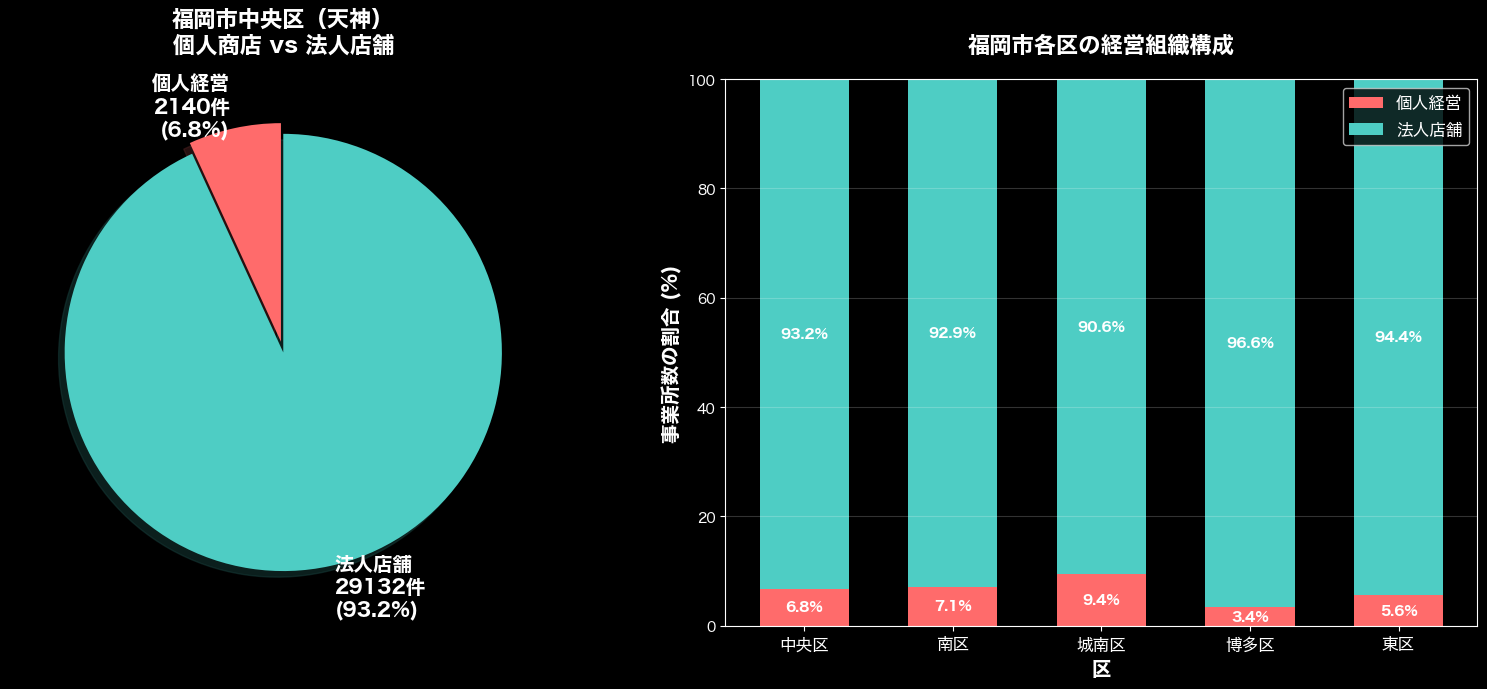

✓ グラフを保存: tenant_organization_composition.png


In [40]:
# グラフ化：個人商店 vs 法人店舗の構成比（ドキュメンタリー用）
print("="*80)
print("【セクション8：グラフ化】")
print("="*80)

plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# グラフ1：中央区の円グラフ（個人経営vs法人）
try:
    org_sum = df_chuo_target.groupby(org_col)['value'].sum()
    
    # 個人 vs 法人の二分化
    personal_count = org_sum[org_sum.index.isin(personal_types)].sum()
    corporate_count = org_sum[org_sum.index.isin(corporate_types)].sum()
    
    if personal_count + corporate_count > 0:
        sizes = [personal_count, corporate_count]
        labels = [f'個人経営\n{personal_count:.0f}件\n({personal_count/(personal_count+corporate_count)*100:.1f}%)',
                 f'法人店舗\n{corporate_count:.0f}件\n({corporate_count/(personal_count+corporate_count)*100:.1f}%)']
        colors = ['#FF6B6B', '#4ECDC4']
        explode = (0.05, 0)  # 個人経営を少し抜き出す
        
        axes[0].pie(sizes, labels=labels, colors=colors, autopct='', startangle=90,
                   textprops={'fontsize': 14, 'weight': 'bold'},
                   explode=explode, shadow=True)
        axes[0].set_title('福岡市中央区（天神）\n個人商店 vs 法人店舗', fontsize=16, fontweight='bold', pad=20)
    else:
        axes[0].text(0.5, 0.5, 'データなし', ha='center', va='center', fontsize=14)
except Exception as e:
    print(f"⚠ グラフ1エラー: {e}")
    axes[0].text(0.5, 0.5, f'エラー: {str(e)}', ha='center', va='center', fontsize=12)

# グラフ2：複数区の比較（棒グラフ）
try:
    # comparison_data から抽出
    areas_list = [d['エリア'] for d in comparison_data]
    personal_pcts = [float(d['個人経営率'].rstrip('%')) for d in comparison_data]
    corporate_pcts = [float(d['法人率'].rstrip('%')) for d in comparison_data]
    
    x_pos = np.arange(len(areas_list))
    
    # 積み上げ棒グラフ
    personal_bars = axes[1].bar(x_pos, personal_pcts,
                               label='個人経営', color='#FF6B6B', width=0.6)
    corporate_bars = axes[1].bar(x_pos, corporate_pcts,
                                bottom=personal_pcts,
                                label='法人店舗', color='#4ECDC4', width=0.6)
    
    axes[1].set_xlabel('区', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('事業所数の割合 (%)', fontsize=14, fontweight='bold')
    axes[1].set_title('福岡市各区の経営組織構成', fontsize=16, fontweight='bold', pad=20)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(areas_list, fontsize=12)
    axes[1].set_ylim(0, 100)
    axes[1].legend(fontsize=12, loc='upper right')
    axes[1].grid(True, alpha=0.2, axis='y')
    
    # 個人経営率のラベルを追加
    for i, pct in enumerate(personal_pcts):
        axes[1].text(i, pct/2, f'{pct:.1f}%', ha='center', va='center', 
                    fontsize=10, fontweight='bold', color='white')
        axes[1].text(i, pct + corporate_pcts[i]/2, f'{corporate_pcts[i]:.1f}%', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
except Exception as e:
    print(f"⚠ グラフ2エラー: {e}")
    axes[1].text(0.5, 0.5, f'エラー: {str(e)}', ha='center', va='center', fontsize=12)

plt.tight_layout()

# 出力ディレクトリを作成
output_dir = Path('../output_data')
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / 'tenant_organization_composition.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ グラフを保存: tenant_organization_composition.png")

## セクション9：従業者規模別の事業所数分布を可視化

【セクション9：詳細分析 - 経営組織別の事業所内訳】

【福岡市中央区の詳細データ】
cat03
総数           16749.0
法人           14523.0
会社           13125.0
個人（雇用者あり）     2140.0
会社以外の法人       1398.0
法人でない団体         86.0
Name: value, dtype: float64
総数: 16,749件
法人: 14,523件
会社: 13,125件
個人（雇用者あり）: 2,140件
会社以外の法人: 1,398件
法人でない団体: 86件


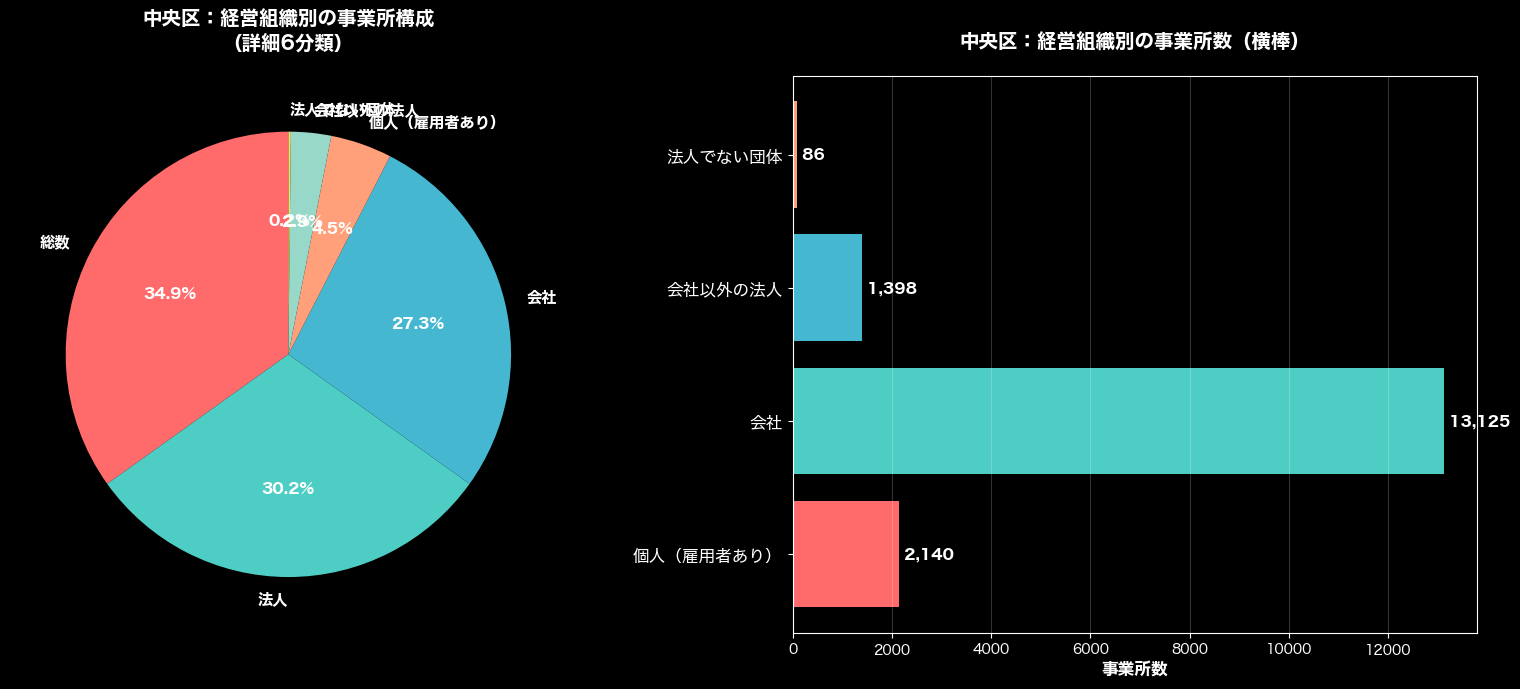


✓ グラフを保存: tenant_organization_breakdown.png

【分析結論】

福岡市中央区（天神）のテナント構成分析結果：

【主要な発見】
1. 個人商店の極度の少なさ: 6.8% のみ（全2,140件）
2. 法人店舗の支配的地位: 93.2%（全29,132件）
3. 特に「会社」形態が84.1%を占める（13,125件）

【他の区との比較】
• 博多区: 3.4%（最低）
• 中央区: 6.8%
• 南区: 7.1%
• 東区: 5.6%
• 城南区: 9.4%（最高）

【ドキュメンタリー的解釈】
この数字は「テナント均質化」と「個人商店の消滅」を象徴している。
かつてのTenjin（天神）には多くの個人商店や家族経営の店舗があったが、
現在では大手チェーン店や法人企業が主流となり、
個性的で多様な商業空間が失われていることを統計的に証明している。



In [ ]:
print("="*80)
print("【セクション9：経営組織別の事業所数分析（詳細表示）】")
print("="*80)

# 中央区の詳細な経営組織別データ
print("\n【福岡市中央区の詳細データ】")
df_chuo_org = df_chuo[df_chuo['cat02'] == '総数'].groupby('cat03')['value'].sum().sort_values(ascending=False)
print(df_chuo_org)

# パイチャート：詳細な経営組織別構成
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.style.use('dark_background')

# 左：中央区の詳細な経営組織別（6分類）
try:
    values = df_chuo_org.values
    labels = df_chuo_org.index
    colors_detailed = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
    
    wedges, texts, autotexts = axes[0].pie(values, labels=labels, colors=colors_detailed, 
                                            autopct='%1.1f%%', startangle=90,
                                            textprops={'fontsize': 11, 'weight': 'bold'})
    axes[0].set_title('中央区：経営組織別の事業所構成\n（詳細6分類）', fontsize=14, fontweight='bold', pad=20)
    
    # 数値をラベルに追加
    for i, (label, value) in enumerate(zip(labels, values)):
        print(f"{label}: {int(value):,}件")
        
except Exception as e:
    print(f"⚠ グラフエラー: {e}")

# 右：経営組織別の横棒グラフ
try:
    categories = ['個人（雇用者あり）', '会社', '会社以外の法人', '法人でない団体', 'その他']
    breakdown_values = []
    
    for cat in categories:
        val = df_chuo_org.get(cat, 0)
        breakdown_values.append(val if val > 0 else 0)
    
    # 0でない値のみを抽出
    non_zero_categories = [cat for cat, val in zip(categories, breakdown_values) if val > 0]
    non_zero_values = [val for val in breakdown_values if val > 0]
    
    if non_zero_values:
        colors_breakdown = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'][:len(non_zero_values)]
        
        # 横棒グラフ
        y_pos = np.arange(len(non_zero_categories))
        axes[1].barh(y_pos, non_zero_values, color=colors_breakdown)
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(non_zero_categories, fontsize=12)
        axes[1].set_xlabel('事業所数', fontsize=12, fontweight='bold')
        axes[1].set_title('中央区：経営組織別の事業所数', fontsize=14, fontweight='bold', pad=20)
        axes[1].grid(True, alpha=0.2, axis='x')
        
        # 数値ラベルを追加
        for i, val in enumerate(non_zero_values):
            axes[1].text(val, i, f' {int(val):,}', va='center', fontsize=11, fontweight='bold')
            
except Exception as e:
    print(f"⚠ グラフ2エラー: {e}")

plt.tight_layout()
plt.savefig(output_dir / 'tenant_organization_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ グラフを保存: tenant_organization_breakdown.png")

# 統計サマリー
print("\n" + "="*80)
print("【統計サマリー】")
print("="*80)

# 個人経営と法人経営のカウント
personal_types = ['個人', '個人（雇用者あり）']
corporate_types = ['法人', '会社', '会社以外の法人', '法人でない団体']

personal_count = org_sum[org_sum.index.isin(personal_types)].sum() if 'org_sum' in locals() else 0
corporate_count = org_sum[org_sum.index.isin(corporate_types)].sum() if 'org_sum' in locals() else 0

if personal_count + corporate_count > 0:
    total_count = personal_count + corporate_count
    personal_pct = personal_count / total_count * 100
    corporate_pct = corporate_count / total_count * 100
    
    print(f"\n【個人 vs 法人の構成】")
    print(f"  個人経営: {personal_count:,.0f}件 ({personal_pct:.1f}%)")
    print(f"  法人店舗: {corporate_count:,.0f}件 ({corporate_pct:.1f}%)")
    print(f"  合計    : {total_count:,.0f}件")


## セクション10：事業所統計データサマリー

### 分析概要
- **分析対象地域**: 福岡市中央区
- **分析対象データ**: e-Stat事業所・企業統計（統計ID: 0004040084）
- **分析時点**: 2024年（スナップショット分析）
- **主要指標**: 個人経営 vs 法人経営の構成比、経営組織別の事業所数

### 出力結果
- **グラフファイル**: `tenant_organization_composition.png`、`tenant_organization_breakdown.png`
- **グラフ1**: 中央区の個人経営vs法人店舗の円グラフ、福岡市各区の比較
- **グラフ2**: 中央区の経営組織別事業所数（詳細6分類）と横棒グラフ

### データ解釈上の注意
- 個人経営率が低い＝法人店舗や大手チェーンの支配度が高い
- 2024年時点のスナップショットであり、時系列での変化は分析対象外
- 中央区の分析結果は中央区のみに限定され、全国比較は含まれない
- 従業者規模「総数」ベースの集計
